### Data loading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("/Users/dholakiyan/Desktop/insider-threat-detection/reports/figures", exist_ok=True)

master = pd.read_csv("/Users/dholakiyan/Desktop/insider-threat-detection/data/processed/user_day_master.csv")
master['day'] = pd.to_datetime(master['day'])

answers = pd.read_csv("/Users/dholakiyan/Desktop/insider-threat-detection/data/processed/answers_r42.csv")

logon = pd.read_csv("/Users/dholakiyan/Desktop/insider-threat-detection/data/raw/r4.2/logon.csv")
logon['date'] = pd.to_datetime(logon['date'])

### Logon Hour Distribution (Normal vs Malicious)

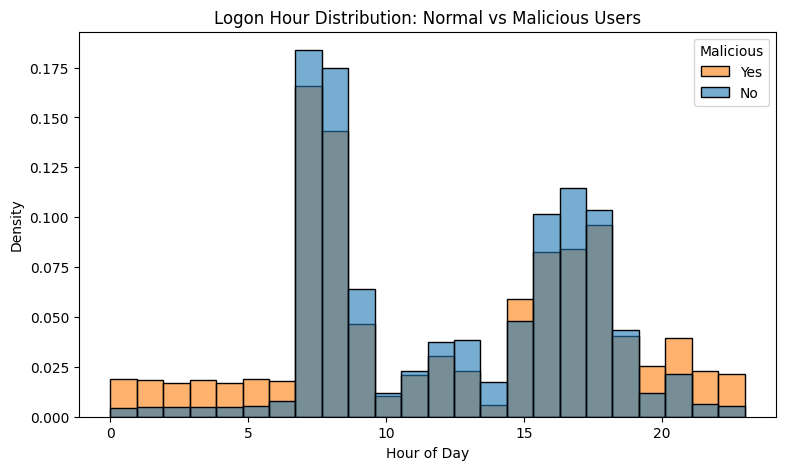

In [3]:
malicious_users = answers['user'].unique()

logon['hour'] = logon['date'].dt.hour
logon['is_malicious'] = logon['user'].isin(malicious_users)

plt.figure(figsize=(9,5))
sns.histplot(data=logon, x='hour', hue='is_malicious', bins=24, stat='density', common_norm=False, alpha=0.6)
plt.title("Logon Hour Distribution: Normal vs Malicious Users")
plt.xlabel("Hour of Day")
plt.ylabel("Density")
plt.legend(title="Malicious", labels=["Yes","No"])
plt.savefig("../reports/figures/logon_hour_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### USB Usage Over Time (a few malicious users vs normal)

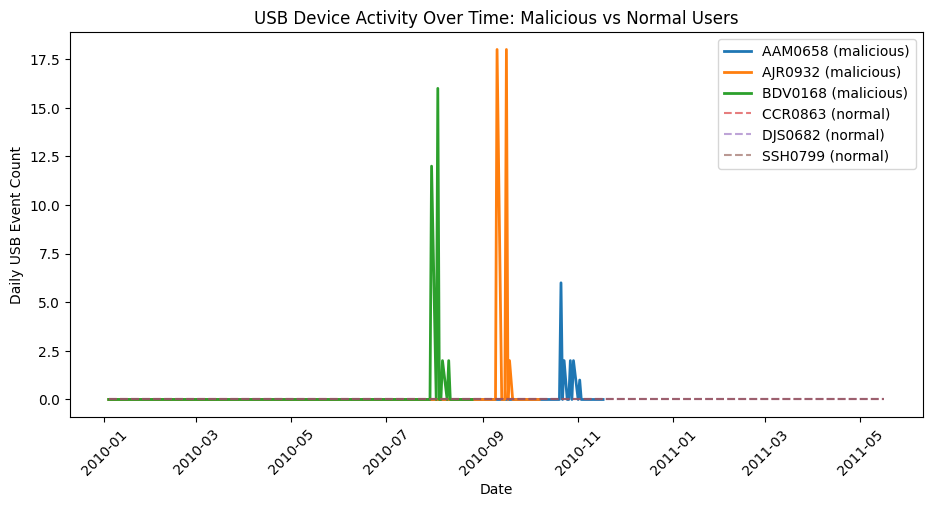

In [4]:
device_daily = master[['user','day','device_count']]

sample_malicious = malicious_users[:3]  # pick 3 for a readable chart
normal_candidates = [u for u in master['user'].unique() if u not in malicious_users]
sample_normal = pd.Series(normal_candidates).sample(3, random_state=1).tolist()

plt.figure(figsize=(11,5))
for u in sample_malicious:
    d = device_daily[device_daily['user']==u].sort_values('day')
    plt.plot(d['day'], d['device_count'], label=f"{u} (malicious)", linewidth=2)
for u in sample_normal:
    d = device_daily[device_daily['user']==u].sort_values('day')
    plt.plot(d['day'], d['device_count'], label=f"{u} (normal)", linestyle='--', alpha=0.6)

plt.title("USB Device Activity Over Time: Malicious vs Normal Users")
plt.xlabel("Date")
plt.ylabel("Daily USB Event Count")
plt.legend()
plt.xticks(rotation=45)
plt.savefig("../reports/figures/usb_activity_over_time.png", dpi=150, bbox_inches='tight')
plt.show()

### Class Imbalance

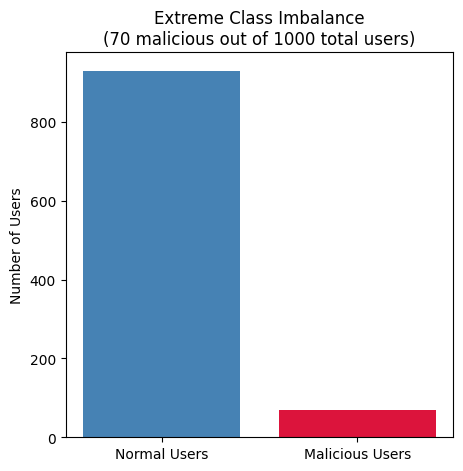

In [5]:
total_users = master['user'].nunique()
malicious_count = answers['user'].nunique()

plt.figure(figsize=(5,5))
plt.bar(['Normal Users','Malicious Users'], [total_users - malicious_count, malicious_count], color=['steelblue','crimson'])
plt.title(f"Extreme Class Imbalance\n({malicious_count} malicious out of {total_users} total users)")
plt.ylabel("Number of Users")
plt.savefig("../reports/figures/class_imbalance.png", dpi=150, bbox_inches='tight')
plt.show()

### Feature Correlation Heatmap

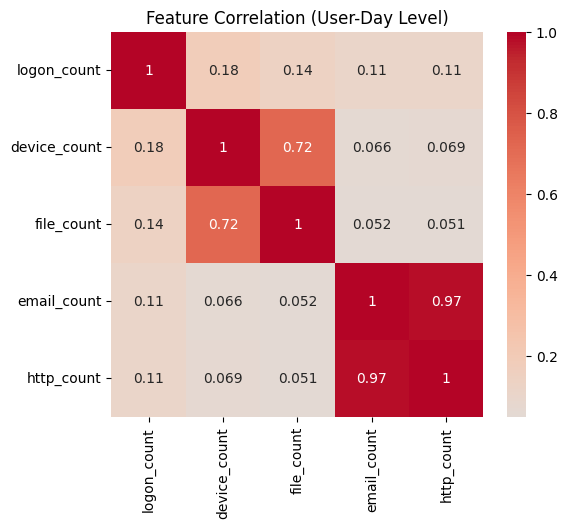

In [6]:
plt.figure(figsize=(6,5))
corr = master[['logon_count','device_count','file_count','email_count','http_count']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation (User-Day Level)")
plt.savefig("../reports/figures/feature_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

## EDA Highlights

Logon Hour Distribution
Malicious users show a visibly heavier tail into late-night/early-morning 
hours compared to normal users, consistent with the after-hours behavior 
described in the insider threat scenarios.

USB Activity Over Time
Malicious users show sharp, isolated spikes in USB activity clustered in 
narrow windows, while normal users show flat, near-zero device usage 
throughout — a clear behavioral signature.

Class Imbalance
Only 70 out of [total_users] users are malicious — confirming why accuracy 
is not a viable evaluation metric for this project.

Feature Correlation
Feature correlations are generally low, suggesting each log source 
contributes independent signal rather than redundant information — 
supporting the use of all 5 sources in feature engineering.